# Финальный проект модуля Python
#  «Анализ данных об оптовых продажах аудиотехники»

**В финальном проекте модуля Python вам предстоит поработать аналитиком данных в компании «Карпов Саунд», которая занимается оптовой продажей аудиотехники и предлагает широкий ассортимент товаров от ведущих мировых брендов, включающий профессиональные аудиосистемы, домашние кинотеатры, портативные аудиоустройства и прочие аксессуары.** 

«Карпов Саунд» сотрудничает с крупными розничными сетями и специализированными магазинами аудиотехники в России. Клиенты компании регулярно оставляют заявки на закупку товаров в CRM системе, менеджеры связываются с клиентами, обсуждают детали, после чего заказы либо подтверждаются менеджерами, либо по разным причинам отменяются. 

В «Карпов Саунд» трепетно относятся к хранению информации о своих товарах, клиентах и заказах, однако в самый неподходящий момент хранилище данных компании оказалось временно недоступно из-за плановых работ по его оптимизации. Поэтому в рамках этого проекта все данные будут представлены не в самом удобном для анализа виде — в формате резервной выгрузки, разложенной по разным папкам на сервере компании.

Вам необходимо собрать данные из разрозненных источников, проанализировать их и сделать выводы, которые помогут руководству компании принять верные тактические решения.

**В ходе работы над проектом вам встретятся следующие таблицы:**  

1) orders (данные о заказах):  
- order_id — номер заказа  
- product_id — идентификатор товара  
- quantity — количество этого товара в заказе

2) order_status (данные о статусах заказов и клиентах):
- order_id — номер заказа  
- client_id — идентификатор клиента  
- status — статус заказа

3) products (данные о товарах):
- id — идентификатор товара  
- name — имя товара (сначала указан бренд, через запятую модель товара)  
- price — цена единицы товара, в долларах

Каждый заказ имеет статус или подтвержденного (`confirmed`), или отмененного (`canceled`). В одном заказе может быть несколько разных товаров. Если заказ был отменен, а потом создан такой же (тем же клиентом, с теми же товарами, у того же менеджера), в базе останется запись о двух заказах с разными номерами и статусами, поскольку система не позволяет создать заказ с тем же номером.

Сначала вам нужно собрать и предобработать три типа датасетов: `orders.csv`, `order_status.csv`, `products.csv`.

На схеме показано, как связаны таблицы между собой:

![](https://storage.yandexcloud.net/klms-public/production/learning-content/457/4167/37264/104636/497986/er_white.png)

Данные находятся в папке `data` из директории `shared` (`shared` -> `homeworks` -> `python_ds_miniprojects` -> `final_project`). Внутри папки `data` находятся 2 другие папки: `orders` и `products`.

В папке `orders` папки с датами, в которые сделаны записи. В этих папках — папки с именами менеджеров по продажам. Эти папки содержат файлы `orders.csv` и `order_status.csv` (в каждой папке по одной паре файлов). Пример структуры: `data` -> `orders` -> `2024-03-01` -> `Алексей Саксофонов` -> `orders.csv` и `order_status.csv`.

В папке `products` папки с категориями товаров. В этих папках файлы `products.csv` (в каждой папке по одному файлу). Пример структуры: `data` -> `products` -> `AV-процессор` -> `products.csv`.

Кроме того у вас есть файл `usd_rate.txt` с курсом доллара США на каждый день анализируемого периода (данные в формате `дата,курс,валюта`). Он потребуется в середине проекта.

В финальном проекте модуля вы можете пользоваться подсказками в ноутбуке (они менее подробные, чем были в предыдущих уроках), обращаться за помощью к экспертам в Discord и смотреть разборы в LMS (за просмотр разбора снимается половина баллов за задание).

### Соберем датасет с заказами по папкам

## Шаг 2

**Ваша первая задача — собрать данные со всех папок в три датафрейма:**  
1. `df_orders` — на основе датасетов `orders.csv` + добавьте колонку `manager` с именами менеджеров и колонку `date` с датами. Отсортируйте датафрейм по возрастанию `order_id` и `product_id`.
2. `df_order_status` — на основе датасетов `order_status.csv`. Отсортируйте датафрейм по возрастанию `order_id`. 
3. `df_products` — на основе датасетов `products.csv` + добавьте колонку `category` с категориями товаров. Отсортируйте датафрейм по возрастанию `id`.  

**Соберите датафреймы и сохраните их в соответствующие csv файлы: `df_orders.csv`, `df_order_status.csv` и `df_products.csv`. Отправьте файлы на проверку в LMS.**

In [188]:
# import pandas as pd
# import os 
# way_to_orders = '/mnt/HC_Volume_18315164/home-jupyter/jupyter-serafim-grishin-rlj8953/shared/homeworks/python_ds_miniprojects/final_project/data'

# data_files = []
# target_files = ['orders.csv', 'order_status.csv', 'products.csv']

# for path, dirs, files in os.walk(way_to_orders):
#     for file in files:
#         if file in target_files:
#             data_file = os.path.join(path, file)
#             data_files.append(data_file)


# df_orders_list = []
# order_status_df_list = []
# products_df_list = []

# df_orders = pd.DataFrame()
# order_status_df = pd.DataFrame()
# products_df = pd.DataFrame()



# for i in data_files:
#     data = pd.read_csv(i)
#     if 'orders.csv' in i:
#         manager = i.split('_manager')[-1].split('_')[0].split('.')[0] if '_manager' in i else 'NaN' 
#         date = i.split('_')[-1].split('.')[0] if '_' in i else 'NaN'
#         data['manager'] = manager
#         data['date'] = date
#         df_orders_list.append(data)
        
#     elif 'products.csv' in i:
#         category = i.split('_category')[-1].split('.')[0] if '_category' in i else 'NaN'
#         data['category'] = category
#         products_df_list.append(data)
        
#     elif 'order_status.csv' in i:
#         order_status_df_list.append(data)

        
# df_orders = pd.concat(df_orders_list, ignore_index=True)
# order_status_df = pd.concat(order_status_df_list, ignore_index=True)
# products_df = pd.concat(products_df_list, ignore_index=True)

# df_orders.to_csv('df_orders', index=False)
# order_status_df.to_csv('order_status_df', index=False)
# products_df.to_csv('products_df', index=False)


import pandas as pd
import os 

way_to_orders = '/mnt/HC_Volume_18315164/home-jupyter/jupyter-serafim-grishin-rlj8953/shared/homeworks/python_ds_miniprojects/final_project/data'

data_files = []
target_files = ['orders.csv', 'order_status.csv', 'products.csv']

for path, dirs, files in os.walk(way_to_orders):
    for file in files:
        if file in target_files:
            data_file = os.path.join(path, file)
            data_files.append(data_file)


df_orders_list = []
order_status_df_list = []
products_df_list = []

for i in data_files:
    data = pd.read_csv(i)

    parts = i.split(os.sep)
    
    if 'orders.csv' in i:
        date = parts[-3]     
        manager = parts[-2]
        
        data['manager'] = manager
        data['date'] = date
        df_orders_list.append(data)
        
    elif 'products.csv' in i:
        filename = os.path.basename(i)
        if '_category_' in filename:
            category = filename.split('_category_')[-1].split('.')[0]
        else:
            category = os.path.basename(os.path.dirname(i))
        data['category'] = category
        products_df_list.append(data)
        
    elif 'order_status.csv' in i:
        order_status_df_list.append(data)



if df_orders_list:
    df_orders = pd.concat(df_orders_list, ignore_index=True)
else:
    df_orders = pd.DataFrame()

if order_status_df_list:
    order_status_df = pd.concat(order_status_df_list, ignore_index=True)
else:
    order_status_df = pd.DataFrame()

if products_df_list:
    products_df = pd.concat(products_df_list, ignore_index=True)
else:
    products_df = pd.DataFrame()


df_orders.to_csv('df_orders.csv', index=False)
order_status_df.to_csv('order_status_df.csv', index=False)
products_df.to_csv('products_df.csv', index=False)




In [25]:
df_orders

,order_id,product_id,quantity,manager,date
0,OTFZ-16952196,520,5,Надежда Гармошкина,2024-03-07
1,OTFZ-16952196,248,2,Надежда Гармошкина,2024-03-07
2,OTFZ-16952196,79,28,Надежда Гармошкина,2024-03-07
3,OTFZ-16952196,579,11,Надежда Гармошкина,2024-03-07
4,OTFZ-16952196,514,17,Надежда Гармошкина,2024-03-07
...,...,...,...,...,...
4598,SAKO-97877276,1156,22,Екатерина Тарелкина,2024-03-19
4599,SAKO-97877276,326,7,Екатерина Тарелкина,2024-03-19
4600,SAKO-97877276,986,10,Екатерина Тарелкина,2024-03-19
4601,SAKO-97877276,1487,10,Екатерина Тарелкина,2024-03-19


### Посмотрим на общую динамику заказов и определим дни, которые выбиваются из общей картины

## Шаг 3

Посчитайте количество заказов в каждый день. **Определите день с наибольшим числом заказов.** Укажите этот день в том формате, в котором он представлен в данных (гггг-мм-дд).

In [189]:
max_quantity_by_day = df_orders.groupby('date').quantity.sum().idxmax()
max_quantity_by_day

'2024-03-14'

## Шаг 4

**Постройте график с количеством заказов по дням и определите, заметна ли в данных сезонность.**

- Да, по выходным заказов намного больше, чем в остальные дни  
- Да, по выходным почти нет заказов  
- Да, по понедельникам заказов всегда больше, чем в остальные дни недели  
- Да, по понедельникам заказов всегда меньше, чем в остальные дни недели  
- Нет, в данных сложно обнаружить какие-то закономерности  

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


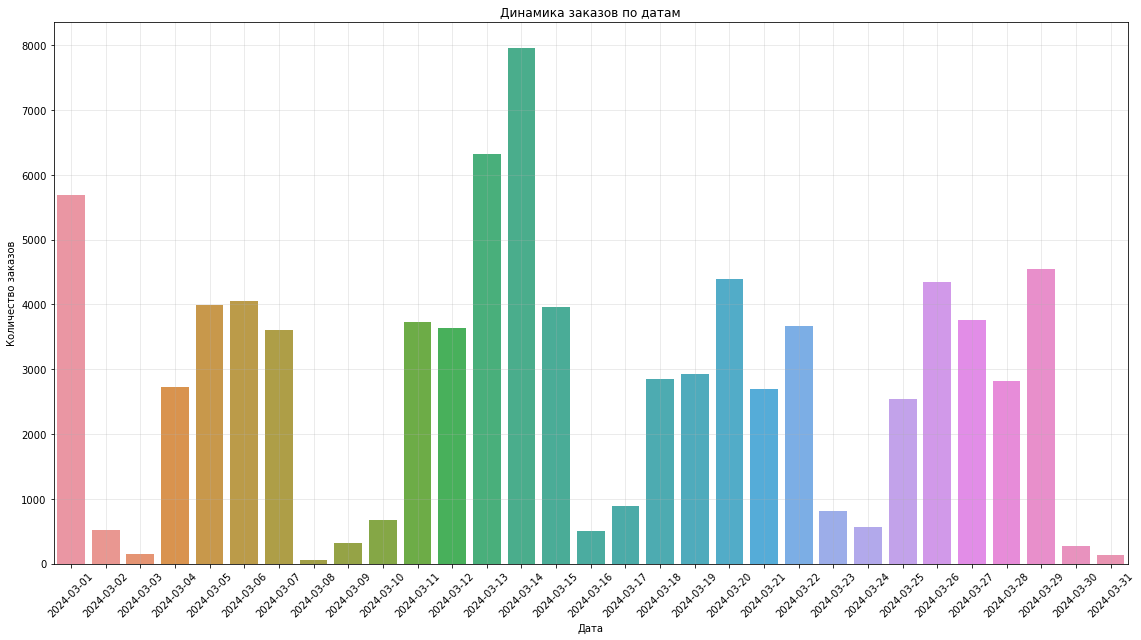

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt


quantity_by_days = df_orders.groupby('date').quantity.sum()
plt.figure(figsize=(16, 9))
# plt.plot(quantity_by_days.index, quantity_by_days.values)

sns.barplot(quantity_by_days.index, quantity_by_days.values)


plt.xticks(rotation=45)
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.title('Динамика заказов по датам')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Шаг 5

**Кажется, в данных помимо дня с наибольшим числом заказов есть еще один день, который выбивается из общей картины.** Что это за день:  
- Это воскресенье, в которое было много заказов?  
- Это понедельник, в который было много заказов?  
- Это пятница, в которую было мало заказов?  
- Это праздничный день, в который было мало заказов?

Подумайте, почему так вышло? Укажите этот день в том формате, в котором он представлен в данных (гггг-мм-дд)

## Шаг 6

К вам пришел радостный руководитель отдела продаж и попросил выяснить причину, почему заказы в один из дней резко подскочили, чтобы и дальше увеличивать продажи.

Возможно, в день с наибольшим числом заказов (который вы определили на третьем шаге) отдел маркетинга запустил какую-то акцию? Или менеджеры стали активнее предлагать компаниям оформить заказ? Нужно подробнее изучить этот день. Начнем со статусов заказа.

**Добавьте к данным о заказах информацию об их статусах. Общий датафрейм назовите `orders_status`. Сохраните получившийся датафрейм в csv файл `orders_status.csv` (при сохранении используйте параметр `index=False`) и отправьте этот csv файл на проверку в LMS.**

In [191]:
orders_status = df_orders.merge(order_status_df, on='order_id')
orders_status.to_csv('orders_status_csv', index=False)
orders_status.client_id.sum()

251232

## Шаг 7

Посмотрите на количество и соотношение подтвержденных и отмененных заказов. **В ответе укажите долю отмененных заказов.** Ответ округлите до двух знаков после точки.

In [192]:


df = orders_status[['order_id', 'status']].drop_duplicates()

# df.groupby('status').order_id.size()


confirmed_orders = df.query('status == "confirmed"').size
canceled_orders = df.query('status == "canceled"').size
round((canceled_orders / (canceled_orders + confirmed_orders)), 2)
df

# status_counts = df['status'].value_counts()


# status_proportions = df['status'].value_counts(normalize=True).round(2)
# status_proportions

,order_id,status
0,OTFZ-16952196,confirmed
13,YSME-13230307,confirmed
25,MBPC-08622706,confirmed
45,BPXU-92126169,confirmed
63,MFXL-78337954,confirmed
...,...,...
4547,PVHE-94485556,confirmed
4563,NSHP-34306143,confirmed
4582,KNDA-07065850,confirmed
4587,QNNY-15640531,confirmed


## Шаг 8

**Посчитайте количество подтвержденных и отмененных заказов на каждую дату.** Определите, в какой день не было ни одного подтвержденного заказа. Для этого сделайте сводную таблицу, где в строках будут даты, в колонках — стутасы заказов, а значения — число заказов с этим статусом в определенную дату. Пропуски заполните нулями.  

**В ответ укажите день, когда не было ни одного подтвержденного заказа.** Дату укажите в том формате, в котором она представлена в данных (гггг-мм-дд).

In [193]:
# orders_status_confirmed = orders_status.query('status == "confirmed"')
# orders_status_confirmed.groupby('date').status.size()

# orders_status_canceled = orders_status.query('status == "canceled"')
# orders_status_canceled.groupby('date').status.size()


orders = orders_status.groupby(['date', 'status'], as_index=False)['order_id'].nunique().rename(columns={'order_id': 'orders'})
pivot_table = orders.pivot(index='date',
                           columns='status',
                           values='orders') \
                    .fillna(0) \
                    .astype({'canceled': 'int',
                            'confirmed': 'int'})




pivot_table.query('confirmed == 0')

    

status,canceled,confirmed
date,,
2024-03-09,1,0


## Шаг 9

**Постройте график с заказами по дням в разбивке по статусу заказа.** Посмотрим подробнее на день с наибольшим числом заказов (вместе и подтвержденных, и отменных), который мы определили ранее, и на день, предшествующий ему. Какой вывод можно сделать? Выберите один или несколько вариантов:

- В день с наибольшим числом заказов было очень много отмен  
- В день с наибольшим числом заказов было много успешно оформленных заказов  
- В день, предшествующий дню с наибольшим числом заказов, было много отмен  
- В день, предшествующий дню с наибольшим числом заказов, было много успешно оформленных заказов  
- В день, предшествующий дню с наибольшим числом заказов, не было ни одного успешно оформленного заказа  
- В день, предшествующий дню с наибольшим числом заказов, не было ни одного отмененного заказа

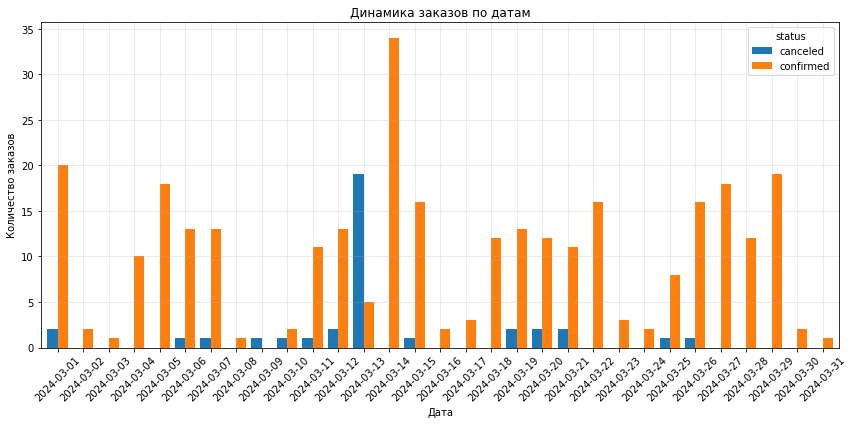

In [194]:



pivot_table.plot(kind='bar', figsize=(12, 6), width=0.8)

plt.xticks(rotation=45)
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.title('Динамика заказов по датам')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Шаг 10

Рассмотрим эти два дня отдельно (день с наибольшим числом заказов, который мы определили ранее, и день, предшествующий ему). Проанализируйте заказы за эти дни и ответьте, какую из этих гипотез можно назвать наиболее правдоподобной.

- Так сложилось, что один день оказался крайне неудачным для отдела продаж, все клиенты отменили свои заказы. А на следующий день отдел продаж пытался компенсировать отсутствие продаж в предыдущий и перевыполнил дневной план. Почти все заказы не повторяют вчерашние  
- Произошел сбой в работе CRM системы, который не позволил клиентам подтвердить заказ. В результате все созданные в первый день заказы автоматически отменились, поэтому клиентам пришлось оформлять их повторно на следующий день. Почти половина заказов повторяет вчерашние

Как можно определить, что заказ повторяет вчерашний? У заказов будут совпадать сразу несколько параметров: клиент, менеджер, количество уникальных товаров в заказе и общее число товаров в штуках. Но номера заказов будут разными.

In [195]:
march_13 = orders_status.query('date == "2024-03-13" and status == "canceled"') \
             .groupby('order_id') \
             .agg({'product_id': 'nunique', 
                 'quantity': 'sum',
                 'manager': 'max', 
                 'client_id': 'max'})



march_14 = orders_status.query('date == "2024-03-14" and status == "confirmed"') \
             .groupby('order_id') \
             .agg({'product_id': 'nunique', 
                 'quantity': 'sum',
                 'manager': 'max', 
                 'client_id': 'max'})


march_13_14 = march_13.merge(march_14, on=['manager', 'client_id', 'product_id', 'quantity'])
len(march_14)/len(march_13_14)

2.125

In [33]:
orders_status

,order_id,product_id,quantity,manager,date,client_id,status
0,OTFZ-16952196,520,5,Надежда Гармошкина,2024-03-07,33,confirmed
1,OTFZ-16952196,248,2,Надежда Гармошкина,2024-03-07,33,confirmed
2,OTFZ-16952196,79,28,Надежда Гармошкина,2024-03-07,33,confirmed
3,OTFZ-16952196,579,11,Надежда Гармошкина,2024-03-07,33,confirmed
4,OTFZ-16952196,514,17,Надежда Гармошкина,2024-03-07,33,confirmed
...,...,...,...,...,...,...,...
4598,SAKO-97877276,1156,22,Екатерина Тарелкина,2024-03-19,5,confirmed
4599,SAKO-97877276,326,7,Екатерина Тарелкина,2024-03-19,5,confirmed
4600,SAKO-97877276,986,10,Екатерина Тарелкина,2024-03-19,5,confirmed
4601,SAKO-97877276,1487,10,Екатерина Тарелкина,2024-03-19,5,confirmed


### Посчитаем ключевые метрики, посмотрим на их динамику и составим небольшой отчет

## Шаг 11

**У вас есть данные за целый месяц, поэтому пора посчитать ключевые метрики этого месяца.** Но вот незадача - в ваших данных цена единицы товара указана в долларах США, потому что закупаете их в долларах, но продаете товары за российские рубли (по тому курсу, который установил Центробанк на дату продажи), а значит и метрики требуется посчитать в рублях. Хорошо, что у вас есть текстовый файл с курсом доллара США на каждую дату. **Откройте файл `usd_rate.txt`, соберите из него датафрейм с 2 колонками: `date` и `currency_rate`. Посчитайте среднее значение курса доллара за месяц.** Результат округлите до двух знаков после точки.

In [196]:
# with open('usd_rate.txt') as file:
#     currency = file.readlines()

    
# data = []    

# for i in currency:
#     str_i = i[:-1].split(',')
#     currency_date = str_i[0]
#     currency_rate = str_i[1]
#     data.append({'date': currency_date, 'currency_rate': currency_rate})

    
# df_currency = pd.DataFrame(data)
# df_currency['date'] = pd.to_datetime(df_currency['date'], format='%Y-%m-%d')
# df_currency['currency_rate'] = df_currency['currency_rate'].astype(float)


# round(df_currency.currency_rate.sum() / 31, 2)
df_currency

,date,currency_rate
0,2024-03-01,90.8423
1,2024-03-02,91.3336
2,2024-03-03,91.3336
3,2024-03-04,91.3336
4,2024-03-05,91.3534
5,2024-03-06,91.1604
6,2024-03-07,90.3412
7,2024-03-08,90.7493
8,2024-03-09,90.7493
9,2024-03-10,90.7493


## Шаг 12

**Работу с ключевыми метриками начните с подсчета общей выручки.** Данные по товарам в подтвержденных заказах у вас есть в датафрейме `orders_status`, а стоимость одной единицы товара можно взять из датафрейма `df_products`. Объедините эти датафреймы в общий `df_full`, добавьте к ним информацию по курсу доллара на каждую дату. Создайте колонку с выручкой для каждого товара в заказах и посчитайте, **чему равна общая выручка в рублях?** Учитывайте только подтвержденные заказы. Результат округлите до двух знаков после точки.

In [197]:
df_full = products_df.merge(orders_status, left_on='id', right_on='product_id', how='inner')
df_full['date'] = pd.to_datetime(df_full['date'])

In [198]:
# df_full = pd.concat([df_full, df_currency], axis=1, join='inner')
df_full = df_full.merge(df_currency, on='date', how='left')

In [199]:
df_full['price_rub'] = df_full['price'] * df_full['currency_rate']
df_full['revenue'] = df_full['price_rub'] * df_full['quantity']
df_full

,id,name,price,category,order_id,product_id,quantity,manager,date,client_id,status,currency_rate,price_rub,revenue
0,57,"Audioengine, A2+",215.22,Активные колонки,CUTE-03167571,57,13,Анастасия Дудкина,2024-03-15,17,confirmed,91.6359,19721.878398,2.563844e+05
1,57,"Audioengine, A2+",215.22,Активные колонки,IECD-18739530,57,13,Виктор Тромбонов,2024-03-14,60,confirmed,91.5449,19702.293378,2.561298e+05
2,57,"Audioengine, A2+",215.22,Активные колонки,WXGQ-76876720,57,17,Виктор Тромбонов,2024-03-14,43,confirmed,91.5449,19702.293378,3.349390e+05
3,57,"Audioengine, A2+",215.22,Активные колонки,AUZX-12706022,57,19,Екатерина Тарелкина,2024-03-14,83,confirmed,91.5449,19702.293378,3.743436e+05
4,57,"Audioengine, A2+",215.22,Активные колонки,FSEW-17069410,57,12,Максим Барабанов,2024-03-27,25,confirmed,92.5745,19923.883890,2.390866e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4598,1627,"Yamaha, NS-777",680.09,Напольная акустика,CUDB-19668701,1627,21,Маргарита Камертонова,2024-03-26,82,confirmed,92.7761,63096.097849,1.325018e+06
4599,1627,"Yamaha, NS-777",680.09,Напольная акустика,KBEJ-06296115,1627,22,Максим Барабанов,2024-03-06,24,confirmed,91.1604,61997.276436,1.363940e+06
4600,1627,"Yamaha, NS-777",680.09,Напольная акустика,MFPO-39782740,1627,14,Анастасия Дудкина,2024-03-22,68,confirmed,91.9499,62534.207491,8.754789e+05
4601,1627,"Yamaha, NS-777",680.09,Напольная акустика,XLNB-27270501,1627,16,Виктор Тромбонов,2024-03-25,82,confirmed,92.6118,62984.359062,1.007750e+06


In [200]:
df_confirmed = df_full.query('status == "confirmed"')
round(df_confirmed.revenue.sum(), 2)

2038231821.56

## Шаг 13

**Следующая метрика, которую вам нужно посчитать — средний чек в этом месяце (в рублях).** Разделите общую выручку на количество заказов. Результат округлите до двух знаков после точки.

In [201]:
avg_check_month = df_confirmed.revenue.sum() / df_confirmed.order_id.nunique()
round(avg_check_month, 2)


6596219.49

## Шаг 14

Ключевые метрики месяца вы посчитали, теперь попробуйте посмотреть на их динамику внутри месяца: посчитайте выручку, средний чек и число заказов — на каждый день. Посмотрите на графики и выберите верные ответы:

- число заказов и выручка каждый день изменяются в одинаковом направлении (если в этот день число заказов выросло, то и выручка выросла; число заказов упало — в этот же день упала и выручка)  
- число заказов и выручка не каждый день изменяются в одинаковом направлении (если в какой-то день число заказов выросло, то выручка может упасть, и наоборот: число заказов упало — в этот же день выручка выросла)  
- средний чек и выручка каждый день изменяются в одинаковом направлении (если в этот день средний чек вырос, то и выручка выросла; средний чек упал — в этот же день упала и выручка)  
- средний чек и выручка не каждый день изменяются в одинаковом направлении (если в какой-то день средний чек вырос, то выручка может упасть, и наоборот: средний чек упал — в этот же день выручка выросла)  
- в день с наибольшим числом заказов и выручка, и средний чек также показывают максимальное значение  
- в день с наибольшим числом заказов выручка и/или средний чек не показывают максимальное значение  
- с течением времени выручка то увеличивается, то уменьшается  
- с течением времени выручка только увеличивается  
- на протяжении всего месяца средний чек то увеличивается, то уменьшается  
- средний чек на протяжении всего месяца имеет одинаковое значение

In [202]:
df_report_by_date = df_confirmed.groupby('date').agg(
    revenue_sum=('revenue', 'sum'),
    orders_count=('order_id', 'nunique')
).reset_index()

df_report_by_date = df_report_by_date.rename(columns={
    'revenue_sum': 'revenue',
    'orders_count': 'orders'
})

df_report_by_date['avg_check'] = round(df_report_by_date['revenue'] / df_report_by_date['orders'], 2)

df_report_by_date = df_report_by_date.sort_values('date')
df_report_by_date

,date,revenue,orders,avg_check
0,2024-03-01,1.554118e+08,20,7770587.80
1,2024-03-02,1.197167e+07,2,5985834.26
2,2024-03-03,2.548418e+06,1,2548418.42
3,2024-03-04,6.404993e+07,10,6404992.56
4,2024-03-05,8.952724e+07,18,4973735.46
5,2024-03-06,1.107687e+08,13,8520669.46
6,2024-03-07,9.102331e+07,13,7001792.83
7,2024-03-08,1.609147e+06,1,1609146.62
8,2024-03-10,8.929309e+06,2,4464654.57
9,2024-03-11,8.910847e+07,11,8100769.59


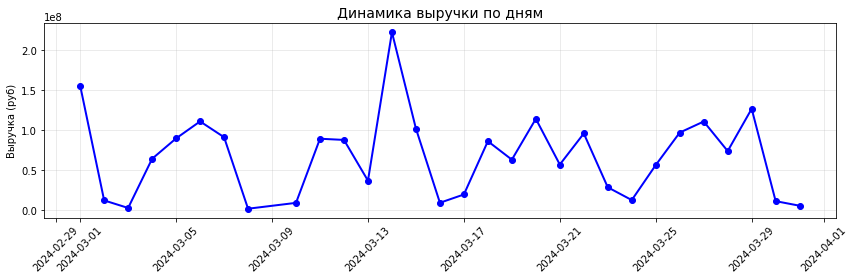

In [203]:
import matplotlib.pyplot as plt

# Простой график выручки
plt.figure(figsize=(12, 4))
plt.plot(df_report_by_date['date'], df_report_by_date['revenue'], marker='o', linewidth=2, color='blue')
plt.title('Динамика выручки по дням', fontsize=14)
plt.ylabel('Выручка (руб)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

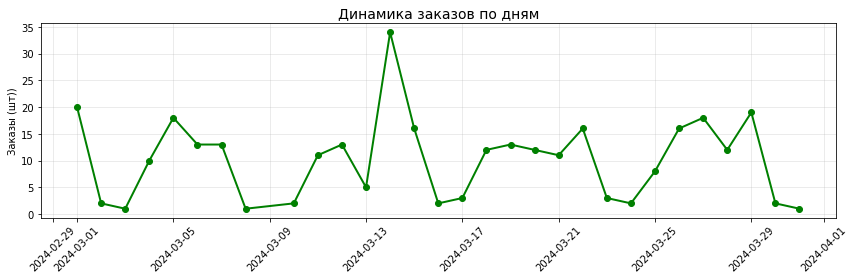

In [112]:
plt.figure(figsize=(12, 4))
plt.plot(df_report_by_date['date'], df_report_by_date['orders'], marker='o', linewidth=2, color='green')
plt.title('Динамика заказов по дням', fontsize=14)
plt.ylabel('Заказы (шт))')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

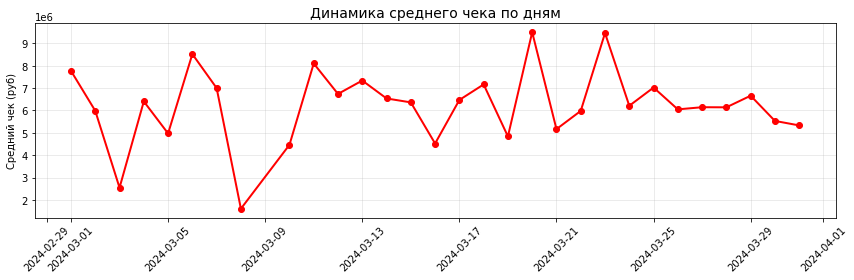

In [113]:
plt.figure(figsize=(12, 4))
plt.plot(df_report_by_date['date'], df_report_by_date['avg_check'], marker='o', linewidth=2, color='red')
plt.title('Динамика среднего чека по дням', fontsize=14)
plt.ylabel('Средний чек (руб)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Проанализируем интерес клиентов к брендам

## Шаг 15

К вам снова обратился руководитель отдела продаж. Он хочет разобраться, какие бренды востребованы среди клиентов, а какие — нет. На основе данных о названиях товаров в датафрейме `df_full` создайте новую колонку `brand`, где будет только название бренда. **Посчитайте, сколькими брендами интересовались клиенты** (статус заказа здесь не важен, если запись о бренде попала в данные о заказах, значит клиент заказал или хотел заказать товар этого бренда).

In [204]:
df_full['brand'] = df_full['name'].str.split(',').str[0]
df_full['brand'].nunique()


121

## Шаг 16

Посчитайте, какую выручку принес каждый бренд и в скольких подтвержденных заказах были товары этого бренда. **Определите, какой бренд принес наибольшую выручку.** В ответ укажите его название.

Дополнительно: проверьте, именно этот бренд встречается в большем количестве заказов, чем другие бренды? Или может его реже заказывают, но на более крупные суммы?

In [205]:
df_full

,id,name,price,category,order_id,product_id,quantity,manager,date,client_id,status,currency_rate,price_rub,revenue,brand
0,57,"Audioengine, A2+",215.22,Активные колонки,CUTE-03167571,57,13,Анастасия Дудкина,2024-03-15,17,confirmed,91.6359,19721.878398,2.563844e+05,Audioengine
1,57,"Audioengine, A2+",215.22,Активные колонки,IECD-18739530,57,13,Виктор Тромбонов,2024-03-14,60,confirmed,91.5449,19702.293378,2.561298e+05,Audioengine
2,57,"Audioengine, A2+",215.22,Активные колонки,WXGQ-76876720,57,17,Виктор Тромбонов,2024-03-14,43,confirmed,91.5449,19702.293378,3.349390e+05,Audioengine
3,57,"Audioengine, A2+",215.22,Активные колонки,AUZX-12706022,57,19,Екатерина Тарелкина,2024-03-14,83,confirmed,91.5449,19702.293378,3.743436e+05,Audioengine
4,57,"Audioengine, A2+",215.22,Активные колонки,FSEW-17069410,57,12,Максим Барабанов,2024-03-27,25,confirmed,92.5745,19923.883890,2.390866e+05,Audioengine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4598,1627,"Yamaha, NS-777",680.09,Напольная акустика,CUDB-19668701,1627,21,Маргарита Камертонова,2024-03-26,82,confirmed,92.7761,63096.097849,1.325018e+06,Yamaha
4599,1627,"Yamaha, NS-777",680.09,Напольная акустика,KBEJ-06296115,1627,22,Максим Барабанов,2024-03-06,24,confirmed,91.1604,61997.276436,1.363940e+06,Yamaha
4600,1627,"Yamaha, NS-777",680.09,Напольная акустика,MFPO-39782740,1627,14,Анастасия Дудкина,2024-03-22,68,confirmed,91.9499,62534.207491,8.754789e+05,Yamaha
4601,1627,"Yamaha, NS-777",680.09,Напольная акустика,XLNB-27270501,1627,16,Виктор Тромбонов,2024-03-25,82,confirmed,92.6118,62984.359062,1.007750e+06,Yamaha


In [206]:
revenue_brand = df_full.query('status == "confirmed"').groupby('brand', as_index=False).agg({'revenue' : 'sum', 'order_id' : 'nunique'})
revenue_brand = revenue_brand.sort_values('revenue', ascending=False)
revenue_brand

,brand,revenue,order_id
46,JBL,2.665961e+08,264
43,Heco,2.388163e+08,229
53,Klipsch,2.039024e+08,205
120,Yamaha,1.658651e+08,218
49,KEF,1.465101e+08,73
...,...,...,...
8,AudioSource,3.388167e+04,1
40,Fosi Audio,3.129419e+04,1
1,ART,2.670040e+04,2
18,Bravo Audio,2.405086e+04,1


## Шаг 17

У одних брендов большинство товаров востребовано клиентами, а у других — клиенты заказывают только небольшую часть товаров, а остальные зря занимают виртуальную «полку» в перечне товаров, продаваемых вашей компанией. **Вам нужно определить, какие бренды редко попадают в заказы, хотя товаров таких брендов на самом деле много.**

Начнем с того, что определим, какие товары из имеющихся в продаже хоть раз заказывали, а какие — нет. Для этого соберите список из перечня уникальных идентификаторов товаров, которые встречаются в датафрейме `df_confirmed`. После этого для каждого товара в датафрейме `df_products` определите, был ли этот товар в списке заказанных товаров в этом месяце или нет: создайте новую колонку `is_in_orders` и заполните её соответственно значениями `yes` или `no` для каждого товара.

**В ответе укажите, сколько товаров были заказаны, а сколько — не были**

In [207]:

products_in_orders = []
products_in_orders.extend(df_confirmed['product_id'].unique().tolist())
len(products_in_orders)

1180

In [208]:
products_df['is_in_orders'] = products_df['id'].isin(products_in_orders).map({True: 'yes', False: 'no'})

In [209]:
products_df['is_in_orders'].value_counts() 
products_df

,id,name,price,category,is_in_orders
0,16,"Adam Audio, T5V",340.14,Активные колонки,no
1,57,"Audioengine, A2+",215.22,Активные колонки,yes
2,131,"Dali, Kubik Free Xtra",328.73,Активные колонки,no
3,132,"Dali, Callisto 6 C",4005.21,Активные колонки,yes
4,133,"Dali, Rubicon 2",3420.75,Активные колонки,no
...,...,...,...,...,...
1672,1623,"Yamaha, NS-F150",323.80,Напольная акустика,yes
1673,1624,"Yamaha, NS-F210",160.71,Напольная акустика,no
1674,1625,"Yamaha, NS-F51",351.70,Напольная акустика,yes
1675,1626,"Yamaha, NS-555",533.53,Напольная акустика,yes


## Шаг 18

Примерно треть товаров не была заказана ни разу в этом месяце. Посмотрим на эти данные в разрезе по брендам. **Определите, у каких брендов доля ни разу не заказанных товаров была больше половины от всех продаваемых товаров этого бренда.** Но не берите в расчет бренды, которые представлены маленьким числом товаров (меньше 15), они не захламляют виртуальную «полку».

Отметьте бренды, у которых доля ни разу не заказанных товаров была больше половины от всех продаваемых товаров этого бренда: 
- AKG  
- ASUS	
- Dali  
- Emotiva  
- KEF  
- Marantz  
- Onkyo  
- Pioneer  
- Yaqin

In [219]:
products_df['brand'] = products_df['name'].str.split(',').str[0]
pr = products_df.groupby(['brand', 'is_in_orders'], as_index=False).agg(
    products=('id', 'nunique')
)


,brand,is_in_orders,products
0,AKG,no,6
1,AKG,yes,5
2,ART,yes,1
3,ASUS,no,1
4,ASUS,yes,2
...,...,...,...
208,Xiaomi,yes,4
209,YAQIN,no,1
210,Yamaha,no,15
211,Yamaha,yes,91


In [224]:
pr['diff'] = 1 - pr.query('is_in_orders == "no"').is_in_orders.count() / pr.is_in_orders.count()
pr.query('products >= 15 and diff > 0.5')


,brand,is_in_orders,products,diff
26,Bose,yes,15,0.568075
44,Dali,no,49,0.568075
45,Dali,yes,18,0.568075
51,Denon,yes,34,0.568075
56,Edifier,no,20,0.568075
57,Edifier,yes,53,0.568075
75,Harman Kardon,no,19,0.568075
76,Harman Kardon,yes,61,0.568075
78,Heco,yes,85,0.568075
83,JBL,yes,108,0.568075


In [223]:
# Создаем колонку с брендом
products_df['brand'] = products_df['name'].str.split(',').str[0].str.strip()

# Создаем колонку is_in_orders (если еще не создали)
products_df['is_in_orders'] = products_df['id'].isin(products_in_orders)

# Группируем по брендам и считаем количество товаров
brand_stats = products_df.groupby('brand', as_index=False).agg(
    total_products=('id', 'count'),           # всего товаров бренда
    ordered_products=('is_in_orders', 'sum')  # сколько заказано (True=1, False=0)
)

# Рассчитываем долю незаказанных товаров
brand_stats['unordered_share'] = 1 - (brand_stats['ordered_products'] / brand_stats['total_products'])

# Фильтруем: бренды с >=15 товарами и долей незаказанных > 0.5
result = brand_stats.query('total_products >= 15 and unordered_share > 0.5')

print("Бренды, у которых >50% товаров не были заказаны:")
print(result[['brand', 'total_products', 'ordered_products', 'unordered_share']].sort_values('unordered_share', ascending=False))

Бренды, у которых >50% товаров не были заказаны:
      brand  total_products  ordered_products  unordered_share
77  Marantz              22                 3         0.863636
32     Dali              67                18         0.731343
94  Pioneer             103                33         0.679612
60      KEF              82                28         0.658537


### Составим отчет по продажам менеджеров

## Шаг 19

Чтобы компания знала, кого из менеджеров отдела продаж премировать, а с кем провести беседу по итогам месяца, **вас попросили сделать отчет по сделкам каждого менеджера**: сколько он оформил подтвержденных заказов и какую выручку они принесли. Но в абсолютных числах вклад каждого сотрудника может быть непонятен. **Поэтому посчитайте значения в процентах: какой % выручки от общей выручки за месяц приходится на каждого менеджера, и какой % заказов от общего числа заказов.** Посчитайте данные и визуализируйте результат, чтобы принимать решение о поощрении или проведении беседы с менеджерами было удобнее. Выберите верные ответы:

- лучшим менеджером по % выручки стала Маргарита Камертонова  
- лучшим менеджером по % заказов стала Маргарита Камертонова  
- первая пятерка менеджеров по % выручки сильно ушла вперед от всех остальных (явно виден большой разрыв между каждым из первой пятерки и каждым из всех остальных менеджеров)  
- в этом месяце нельзя выделить явную пятерку лидеров по % выручки, которые сильно оторвались от остальных  
- лидер по % заказов реализовал более 16% заказов  
- лидер по % заказов реализовал менее 16% заказов  
- наихудшие показатели у Сергея Контрабасова  
- наихудшие показатели у Аркадия Октавина  
- Антон Скрипкин принес в 3 раза меньше выручки, чем Виктор Тромбонов  
- Антон Скрипкин реализовал почти в 3 раза меньше заказов, чем Анастасия Дудкина

In [248]:
manager_stats = df_confirmed.groupby('manager', as_index=False).agg(
    revenue=('revenue', 'sum'), 
    orders=('order_id','count')
)
manager_stats = manager_split.sort_values('revenue', ascending=False)
manager_stats['revenue_pct'] = round(manager_stats['revenue'] / manager_stats['revenue'].sum() * 100, 2)
manager_stats['orders_pct'] = round(manager_stats['orders'] / manager_stats['orders'].sum() * 100, 2)
manager_stats

,manager,revenue,orders,revenue_perc,orders_perc,revenue_pct,orders_pct
9,Маргарита Камертонова,3.473886e+08,678,17.04,16.61,17.04,16.61
4,Виктор Тромбонов,3.188999e+08,641,15.65,15.70,15.65,15.70
8,Максим Барабанов,2.401478e+08,502,11.78,12.29,11.78,12.29
5,Владимир Ударников,2.084865e+08,423,10.23,10.36,10.23,10.36
0,Алексей Саксофонов,1.953435e+08,391,9.58,9.58,9.58,9.58
7,Ксения Балалайкина,1.817621e+08,341,8.92,8.35,8.92,8.35
6,Екатерина Тарелкина,1.781576e+08,356,8.74,8.72,8.74,8.72
10,Надежда Гармошкина,1.347836e+08,254,6.61,6.22,6.61,6.22
1,Анастасия Дудкина,1.234504e+08,271,6.06,6.64,6.06,6.64
2,Антон Скрипкин,5.150268e+07,98,2.53,2.40,2.53,2.40


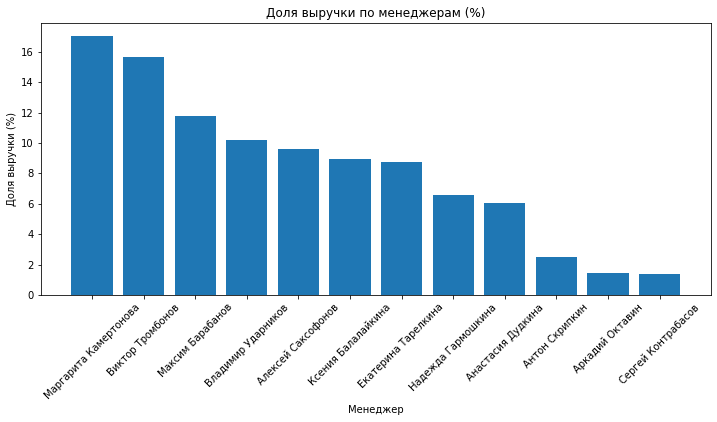

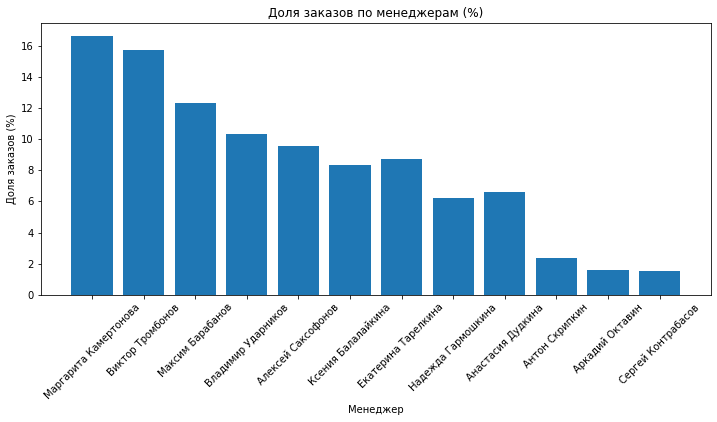

In [249]:
plt.figure(figsize=(12, 5))
plt.bar(manager_stats['manager'], manager_stats['revenue_pct'])
plt.title('Доля выручки по менеджерам (%)')
plt.xlabel('Менеджер')
plt.ylabel('Доля выручки (%)')
plt.xticks(rotation=45)
plt.show()

# График 2: % заказов
plt.figure(figsize=(12, 5))
plt.bar(manager_stats['manager'], manager_stats['orders_pct'])
plt.title('Доля заказов по менеджерам (%)')
plt.xlabel('Менеджер')
plt.ylabel('Доля заказов (%)')
plt.xticks(rotation=45)
plt.show()